In [1]:
import pandas as pd

In [2]:
import numpy as np

In [5]:
df= pd.read_csv(r"D:\Kruthika\PROJECTS\Enrollment_Insurance\employee_data.csv")

In [7]:
print(df.columns)

Index(['employee_id', 'age', 'gender', 'marital_status', 'salary',
       'employment_type', 'region', 'has_dependents', 'tenure_years',
       'enrolled'],
      dtype='object')


In [9]:
print(df["enrolled"].nunique())

2


In [11]:
df.head()

,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled
0,10001,60,Female,Single,55122.97,Part-time,West,No,1.5,0
1,10002,50,Female,Single,89549.66,Full-time,West,Yes,12.8,1
2,10003,36,Male,Divorced,74145.66,Part-time,Midwest,No,3.8,0
3,10004,64,Female,Married,53877.83,Full-time,Northeast,No,3.3,0
4,10005,29,Male,Single,63404.63,Contract,Midwest,Yes,10.0,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   employee_id      10000 non-null  int64  
 1   age              10000 non-null  int64  
 2   gender           10000 non-null  object 
 3   marital_status   10000 non-null  object 
 4   salary           10000 non-null  float64
 5   employment_type  10000 non-null  object 
 6   region           10000 non-null  object 
 7   has_dependents   10000 non-null  object 
 8   tenure_years     10000 non-null  float64
 9   enrolled         10000 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 781.4+ KB


In [15]:
df.describe()

,employee_id,age,salary,tenure_years,enrolled
count,10000.00000,10000.0000,10000.000000,10000.000000,10000.000000
mean,15000.50000,43.0020,65032.967907,3.967720,0.617400
std,2886.89568,12.2858,14923.958446,3.895488,0.486046
min,10001.00000,22.0000,2207.790000,0.000000,0.000000
25%,12500.75000,33.0000,54714.342500,1.200000,0.000000
50%,15000.50000,43.0000,65056.050000,2.800000,1.000000
75%,17500.25000,54.0000,75053.687500,5.600000,1.000000
max,20000.00000,64.0000,120312.000000,36.000000,1.000000


In [17]:
df.isnull().sum()

employee_id        0
age                0
gender             0
marital_status     0
salary             0
employment_type    0
region             0
has_dependents     0
tenure_years       0
enrolled           0
dtype: int64

In [19]:
df.shape

(10000, 10)

In [21]:
##drop Raw Employee IDs which are not useful for model training
df.drop(columns=["employee_id"], inplace=True)

## **Q1: Data Cleaning including missing values, outliers and multi-collinearity.**
The dataset contained 0 missing values, so no imputation was required. For potential outliers in numeric features such as age, salary, and tenure_years, we are visualizing their distributions using histograms and boxplots, and detect extreme values using the IQR method. We decided not to remove these points because unusually high or low salary or tenure can legitimately influence an employee’s likelihood to enroll, and arbitrarily clipping them could remove meaningful signal. Instead, we rely on tree-based models (e.g., Random Forest / Gradient Boosting) that are relatively robust to outliers in the input features.

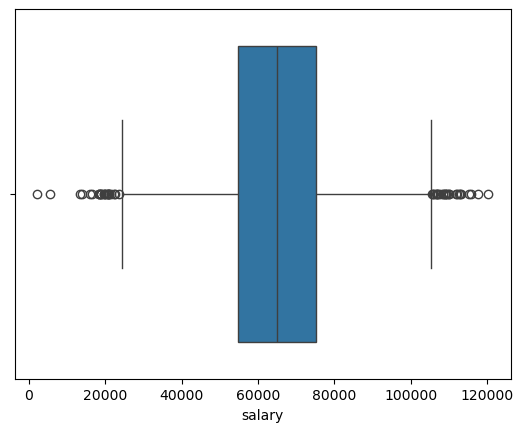

In [23]:
#visualizing using boxplot and histogram
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['salary'])
plt.show()

In [25]:
#detecting outliers[IQR method]
Q1= df['salary'].quantile(0.25)
Q3= df['salary'].quantile(0.75)
IQR= Q3 - Q1

lower_bound= Q1 - 1.5*IQR
upper_bound= Q3 - 1.5*IQR

outliers= df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]

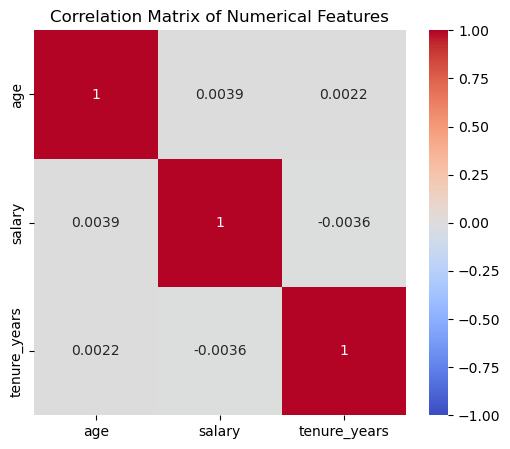

                   age    salary  tenure_years
age           1.000000  0.003872      0.002220
salary        0.003872  1.000000     -0.003574
tenure_years  0.002220 -0.003574      1.000000
Correlation between age and salary:  0.0038719598230387594
Correlation between age and tenure_years:  0.002219744605715958
Correlation between salary and tenure_years:  -0.003574098802578011


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ["age", "salary", "tenure_years"]

#checking multicollinearity
plt.figure(figsize=(6, 5))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

print(correlation_matrix)

#addressing multicollinearity
print("Correlation between age and salary: ",
      correlation_matrix.loc["age", "salary"])

print("Correlation between age and tenure_years: ",
      correlation_matrix.loc["age", "tenure_years"])

print("Correlation between salary and tenure_years: ",
      correlation_matrix.loc["salary", "tenure_years"])

**For numeric features (age, salary, tenure_years), we computed a correlation matrix to check for multicollinearity. While some moderate correlations are expected (e.g., between tenure and salary), these features represent distinct concepts and are all relevant for modeling enrollment. Therefore, we chose to retain all three and rely on tree-based models, which are less sensitive to multicollinearity, instead of dropping or aggressively combining them.**

In [29]:


# 1. Binary dependent flag
# Converts Yes/No into 1/0 for modeling
df["dependents_flag"] = df["has_dependents"].map({"Yes": 1, "No": 0})

# 2. Stable employment flag
# Full-time often implies more stability and possibly more benefit uptake
df["is_stable_employee"] = (df["employment_type"] == "Full-time").astype(int)

# 3. Contract worker flag
# Captures whether the employee might be less attached to employer benefits
df["is_contract"] = (df["employment_type"] == "Contract").astype(int)

# 4. Early tenure flag
# New employees may be less likely to enroll immediately
df["is_early_tenure"] = (df["tenure_years"] < 1).astype(int)

# 5. Long tenure flag
# Long-tenured employees may be more engaged with benefits
df["is_long_tenure"] = (df["tenure_years"] >= 5).astype(int)

# 6. Salary per tenure
# Proxy for compensation progression / maturity inside company
df["salary_per_tenure"] = df["salary"] / (df["tenure_years"] + 1)

print(df.shape)
print(df.head())

(10000, 15)
   age  gender marital_status    salary employment_type     region  \
0   60  Female         Single  55122.97       Part-time       West   
1   50  Female         Single  89549.66       Full-time       West   
2   36    Male       Divorced  74145.66       Part-time    Midwest   
3   64  Female        Married  53877.83       Full-time  Northeast   
4   29    Male         Single  63404.63        Contract    Midwest   

  has_dependents  tenure_years  enrolled  dependents_flag  is_stable_employee  \
0             No           1.5         0                0                   0   
1            Yes          12.8         1                1                   1   
2             No           3.8         0                0                   0   
3             No           3.3         0                0                   1   
4            Yes          10.0         0                1                   0   

   is_contract  is_early_tenure  is_long_tenure  salary_per_tenure  
0          

In [31]:
df['enrolled'].value_counts()

enrolled
1    6174
0    3826
Name: count, dtype: int64

In [33]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Copy so we don't overwrite original
df_clean = df.copy()

# 1. Choose features for anomaly detection
numeric_cols = ['age', 'salary', 'tenure_years']  # adjust if needed

# Optional scale numeric features
scaler = StandardScaler()
X_num = scaler.fit_transform(df_clean[numeric_cols])

# 2. Fit Isolation Forest
iso_forest = IsolationForest(
    contamination=0.01,   # assume ~1% rows are outliers
    random_state=42
)

anomaly_labels = iso_forest.fit_predict(X_num)  # 1 = normal, -1 = anomaly

# 3. Convert to feature
df_clean['is_outlier'] = (anomaly_labels == -1).astype(int)

print("Number of outliers detected:", df_clean['is_outlier'].sum())
print("Dataset shape after adding feature:", df_clean.shape)

Number of outliers detected: 100
Dataset shape after adding feature: (10000, 16)


In [35]:
df.head()

,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled,dependents_flag,is_stable_employee,is_contract,is_early_tenure,is_long_tenure,salary_per_tenure
0,60,Female,Single,55122.97,Part-time,West,No,1.5,0,0,0,0,0,0,22049.188000
1,50,Female,Single,89549.66,Full-time,West,Yes,12.8,1,1,1,0,0,1,6489.105797
2,36,Male,Divorced,74145.66,Part-time,Midwest,No,3.8,0,0,0,0,0,0,15447.012500
3,64,Female,Married,53877.83,Full-time,Northeast,No,3.3,0,0,1,0,0,0,12529.727907
4,29,Male,Single,63404.63,Contract,Midwest,Yes,10.0,0,1,0,1,0,1,5764.057273


In [51]:
from sklearn.model_selection import train_test_split

# Make sure df_clean has ALL features + 'enrolled' and nothing weird
print(df_clean.shape)
print(df_clean.columns)

X = df_clean.drop(columns=["enrolled"])
y = df_clean["enrolled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

(10000, 16)
Index(['age', 'gender', 'marital_status', 'salary', 'employment_type',
       'region', 'has_dependents', 'tenure_years', 'enrolled',
       'dependents_flag', 'is_stable_employee', 'is_contract',
       'is_early_tenure', 'is_long_tenure', 'salary_per_tenure', 'is_outlier'],
      dtype='object')
X_train: (8000, 15)
X_test: (2000, 15)
y_train: (8000,)
y_test: (2000,)


In [55]:
print(X_train.shape)
print(X_test.shape)
print(X_train.index[:10])
print(X_test.index[:10])

(8000, 15)
(2000, 15)
Index([9019, 1629, 4815, 5421, 5895, 1039, 6411, 5133, 3476, 7431], dtype='int64')
Index([9477, 448, 7297, 8636, 2683, 4803, 8522, 236, 2138, 432], dtype='int64')


In [39]:
!pip install xgboost

In [40]:
!pip show xgboost

Name: xgboost
Version: 3.0.2
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: C:\Users\Krutika\anaconda3\Lib\site-packages
Requires: numpy, scipy
Required-by: 


In [43]:
import sys
print(sys.executable)


C:\Users\Krutika\anaconda3\python.exe


In [45]:
import xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [47]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [61]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Identify numeric and categorical columns on X_train
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

# 2. Fit encoder on train only
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])

ohe_feature_names = ohe.get_feature_names_out(categorical_cols)

# 3. Separate numeric part (keep same rows as X_train/X_test)
X_train_num = X_train[numeric_cols]
X_test_num = X_test[numeric_cols]

# 4. Build encoded DataFrames using the SAME indices
X_train_enc = pd.DataFrame(
    X_train_cat,
    columns=ohe_feature_names,
    index=X_train.index
)
X_test_enc = pd.DataFrame(
    X_test_cat,
    columns=ohe_feature_names,
    index=X_test.index
)

# 5. Combine numeric + encoded categorical
X_train_enc = pd.concat([X_train_num, X_train_enc], axis=1)
X_test_enc = pd.concat([X_test_num, X_test_enc], axis=1)

print("Encoded X_train_enc:", X_train_enc.shape)
print("Encoded X_test_enc:", X_test_enc.shape)
print("y_train length:", len(y_train))
print(X_train_enc.shape[0], len(y_train))

Numeric: ['age', 'salary', 'tenure_years', 'dependents_flag', 'salary_per_tenure']
Categorical: ['gender', 'marital_status', 'employment_type', 'region', 'has_dependents']
Encoded X_train_enc: (8000, 21)
Encoded X_test_enc: (2000, 21)
y_train length: 8000
8000 8000


In [84]:
print(len(X_train_enc), len(y_train))
print(X_train.index[:5], y_train.index[:5])

9570 8000
Index([9019, 1629, 4815, 5421, 5895], dtype='int64') Index([9019, 1629, 4815, 5421, 5895], dtype='int64')


In [65]:
#First Hyperparametr tuning
from sklearn.metrics import classification_report, roc_auc_score

# Define the model
xgb = XGBClassifier(
    tree_method="hist",
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

# Hyperparameter search space
param_distributions = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [3, 6],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "gamma": [0.0, 0.1, 0.3],
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_enc, y_train)

best_xgb = random_search.best_estimator_

print("Best Hyperparameters:", random_search.best_params_)
print("Best CV F1 Score:", random_search.best_score_)
print("Best Model:", best_xgb)

Best Hyperparameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.3, 'gamma': 0.0, 'colsample_bytree': 0.9}
Best CV F1 Score: 0.9997976118008172
Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [67]:
#Second Hyperparameter tuning

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# Model
xgb = XGBClassifier(
    tree_method="hist",
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

# Param distributions (same as you wrote)
param_distributions = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [3, 6],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3],
    "scale_pos_weight": [1, 5, 10],
    "reg_alpha": [0, 0.1, 1, 10, 100],
    "reg_lambda": [0.1, 1, 10, 100],
}

# Randomized search on ENCODED X
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=20,   # 2 is just a quick test; for real use 20–50
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_enc, y_train)

best_xgb = random_search.best_estimator_

print("Best Hyperparameters:", random_search.best_params_)
print("Best F1 Score:", random_search.best_score_)
print("Best Model:", best_xgb)


Best Hyperparameters: {'subsample': 0.7, 'scale_pos_weight': 1, 'reg_lambda': 100, 'reg_alpha': 10, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best F1 Score: 0.9997976118008172
Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parall

In [69]:
# Third hyperparameter tuning

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, classification_report, roc_auc_score

# Handle class imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Base model
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    use_label_encoder=False,
    eval_metric="aucpr",
    random_state=42
)

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [3, 6],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.1, 1, 10, 100],
    "reg_lambda": [0.1, 1, 10, 100],
}

# F1 scorer
f1_scorer = make_scorer(f1_score, pos_label=1)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=2,          # bada tuning ke liye 20+ karo
    scoring=f1_scorer,
    cv=2,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    error_score="raise",
)

# IMPORTANT: use X_train_enc, not X_train
random_search.fit(X_train_enc, y_train)

# Best model and params
best_params = random_search.best_params_
best_score = random_search.best_score_
best_xgb = random_search.best_estimator_


Fitting 2 folds for each of 2 candidates, totalling 4 fits


In [71]:
print("✅ Best Hyperparameters:", random_search.best_params_)
print("✅ Best F1 Score:", random_search.best_score_)
print("✅ Best Model:", best_xgb)

✅ Best Hyperparameters: {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7}
✅ Best F1 Score: 0.9991894629194472
✅ Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)


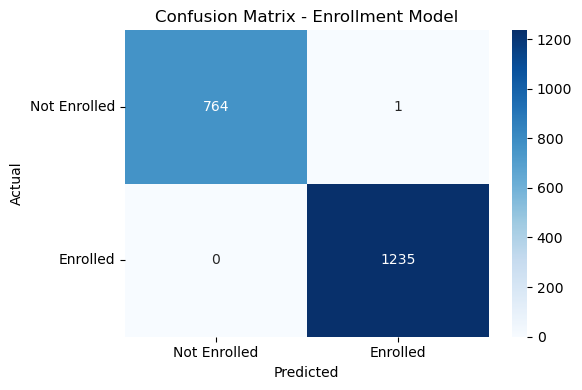

Classification Report:

              precision    recall  f1-score   support

Not Enrolled       1.00      1.00      1.00       765
    Enrolled       1.00      1.00      1.00      1235

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC AUC Score: 0.9994787118626128


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. Predictions on encoded test data
y_pred = best_xgb.predict(X_test_enc)
y_pred_proba = best_xgb.predict_proba(X_test_enc)[:, 1]  # probabilities for ROC AUC

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Class names for your problem
class_names = ['Not Enrolled', 'Enrolled']

plt.xticks([0.5, 1.5], class_names)
plt.yticks([0.5, 1.5], class_names, rotation=0)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Enrollment Model')
plt.tight_layout()
plt.show()

# 3. Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# 4. ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC Score:", roc_auc)

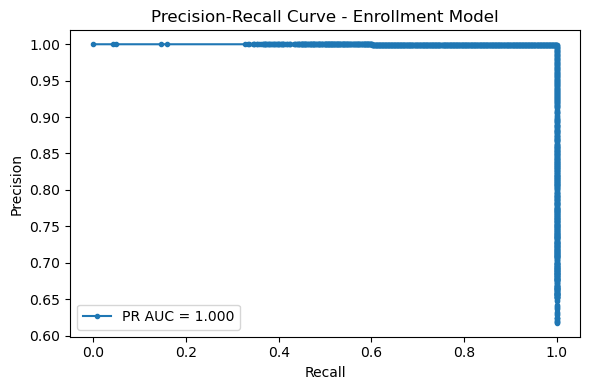

In [75]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# y_test: true labels for enrollment (0/1)
# y_pred_proba: best_xgb.predict_proba(X_test_enc)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Enrollment Model')
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

# Probabilities from best model on encoded test set
y_pred_proba = best_xgb.predict_proba(X_test_enc)[:, 1]

# Threshold optimization for F1
thresholds = np.linspace(0, 1, 100)
f1_scores = []

for t in thresholds:
    y_thresh = (y_pred_proba > t).astype(int)
    f1_scores.append(f1_score(y_test, y_thresh))

best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Probability Threshold:", best_threshold)

# Apply optimized threshold
y_final = (y_pred_proba > best_threshold).astype(int)

class_names = ["Not Enrolled", "Enrolled"]
print(
    "Updated Classification Report with optimized threshold:\n",
    classification_report(y_test, y_final, target_names=class_names)
)

Best Probability Threshold: 0.4141414141414142
Updated Classification Report with optimized threshold:
               precision    recall  f1-score   support

Not Enrolled       1.00      1.00      1.00       765
    Enrolled       1.00      1.00      1.00      1235

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [81]:
from sklearn.metrics import accuracy_score

# For default 0.5 threshold
y_pred = best_xgb.predict(X_test_enc)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 0.9995
